<div style="
    background-color: #262524; 
    padding: 25px; 
    border-radius: 12px; 
    border-left: 10px solid #D96D55; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 2px 2px 15px rgba(0,0,0,0.3);
    max-width: 100%;
    box-sizing: border-box;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 30px; margin-right: 15px;">🚀</span>
        <h1 style="color: #D99B77; margin: 0; font-size: 24px; text-transform: uppercase; letter-spacing: 2px;">
            Configuración del Entorno
        </h1>
    </div>
    <hr style="border: 0; border-top: 1px solid #8C533E; margin-bottom: 15px;">
    <p style="color: #f2f2f2; font-size: 15px; line-height: 1.6; margin: 0;">
        Preparación de la infraestructura técnica. En esta celda se instalan las librerías esenciales para el procesamiento de lenguaje natural y modelos de aprendizaje profundo, incluyendo 
        <b style="color: #F23838;">NLTK</b>, <b style="color: #F23838;">spaCy</b> y <b style="color: #F23838;">PyTorch</b>; entre otras. Solo con descomentar la línea y ejecutar la celda, es suficiente para correr la instalación.
    </p>
</div>

In [ ]:
# ==============================================================================
# INSTALACIÓN DE LIBRERÍAS
# ==============================================================================
# !pip install pandas numpy matplotlib seaborn
# !pip install nltk spacy scikit-learn
# !pip install torch torchvision torchaudio
# !pip install tensorflow
# !pip install --upgrade pip
# !pip install transformers

# Procesar textos en español
# !python -m spacy download es_core_news_sm

# Procesar textos en inglés
# !python -m spacy download en_core_web_sm

# Descarga de recursos
# import nltk
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('stopwords')

<div style="
background-color: #262524;
padding: 25px;
border-radius: 12px;
border-left: 10px solid #D99B77;
font-family: sans-serif;
box-shadow: 2px 2px 15px rgba(0,0,0,0.3);
max-width: 100%;
box-sizing: border-box;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 30px; margin-right: 15px;">📦</span>
        <h1 style="color: #D99B77; margin: 0; font-size: 22px; text-transform: uppercase; letter-spacing: 2px;">Importación de Librerías</h1>
    </div>
    <hr style="border: 0; border-top: 1px solid #8C533E; margin-bottom: 15px;">
    <p style="color: #f2f2f2; font-size: 15px; margin: 0;">
        Carga de módulos para manipulación de datos (<b style="color: #D96D55;">Pandas, NumPy</b>), visualización (<b style="color: #D96D55;">Matplotlib, Seaborn</b>) y procesamiento avanzado de texto.
    </p>
</div>

In [ ]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# NLP
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

import spacy

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

<div style="background-color: #262524; padding: 25px; border-radius: 12px; border-left: 10px solid #8C533E; font-family: sans-serif; max-width: 100%; box-sizing: border-box;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 30px; margin-right: 15px;">🍷</span>
        <h1 style="color: #D99B77; margin: 0; font-size: 22px; text-transform: uppercase; letter-spacing: 2px;">Ingesta y Primer Vistazo</h1>
    </div>
    <hr style="border: 0; border-top: 1px solid #D96D55; margin-bottom: 15px;">
    <p style="color: #f2f2f2; font-size: 15px; margin: 0;">
        Lectura del archivo <i>winemag-data.csv</i>. Se realiza una previsualización de los primeros 5 registros para validar la correcta carga de los delimitadores y la estructura de las reseñas.
    </p>
</div>

In [3]:
# Ruta del archivo o nombre
file_path = 'winemag-data.csv'

try:
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    
    print(f"✅ ¡Dataset cargado!")

except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{file_path}'.")

✅ ¡Dataset cargado!


In [4]:
# Visualización de los primeros 5 registros
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


<div style="background-color: #262524; padding: 25px; border-radius: 12px; border-left: 10px solid #D96D55; font-family: sans-serif; max-width: 100%; box-sizing: border-box;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 30px; margin-right: 15px;">📊</span>
        <h1 style="color: #D99B77; margin: 0; font-size: 22px; text-transform: uppercase; letter-spacing: 2px;">Exploración de Dimensiones</h1>
    </div>
    <hr style="border: 0; border-top: 1px solid #8C533E; margin-bottom: 15px;">
    <p style="color: #f2f2f2; font-size: 15px; margin: 0;">
        Análisis de la volumetría del dataset: verificación del total de registros, tipos de datos por columna y detección de la composición general de las variables.
    </p>
</div>

In [ ]:
# Verificación general de los registros
print(f"Total de registros: {len(df)}")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas disponibles: {df.columns}")

Total de registros: 129971
Dimensiones del dataset: (129971, 14)
Columnas disponibles: Index(['Unnamed: 0', 'country', 'description', 'designation', 'points',
       'price', 'province', 'region_1', 'region_2', 'taster_name',
       'taster_twitter_handle', 'title', 'variety', 'winery'],
      dtype='str')


In [ ]:
# Genera un resumen del DataFrame incluyendo tipos de datos y conteo de valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             129971 non-null  int64  
 1   country                129908 non-null  str    
 2   description            129971 non-null  str    
 3   designation            92506 non-null   str    
 4   points                 129971 non-null  int64  
 5   price                  120975 non-null  float64
 6   province               129908 non-null  str    
 7   region_1               108724 non-null  str    
 8   region_2               50511 non-null   str    
 9   taster_name            103727 non-null  str    
 10  taster_twitter_handle  98758 non-null   str    
 11  title                  129971 non-null  str    
 12  variety                129970 non-null  str    
 13  winery                 129971 non-null  str    
dtypes: float64(1), int64(2), str(11)
memory usage: 

<div style="background-color: #262524; padding: 25px; border-radius: 12px; border-left: 10px solid #F23838; font-family: sans-serif; max-width: 100%; box-sizing: border-box;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 30px; margin-right: 15px;">🧹</span>
        <h1 style="color: #D99B77; margin: 0; font-size: 22px; text-transform: uppercase; letter-spacing: 2px;">Calidad de Datos y Limpieza</h1>
    </div>
    <hr style="border: 0; border-top: 1px solid #D96D55; margin-bottom: 15px;">
    <p style="color: #f2f2f2; font-size: 15px; margin: 0;">
        Proceso de sanitización: renombrado de columnas, detección de <b style="color: #D96D55;">nulos y duplicados</b>, y limpieza inicial de campos críticos como <i>description</i> y <i>designation</i>.
    </p>
</div>

In [ ]:
# Renombrar la primera columna a 'id' para mayor claridad
df.rename(columns={df.columns[0]: 'id'}, inplace=True)

In [ ]:
# Detección de Valores nulos
null_count = df.isnull().sum()

# Detección de duplicados
duplicate_count = df.duplicated().sum()

print(f"--- Reporte de integridad ---")
print(f"Valores nulos:\n{null_count}\n")
print(f"Registros duplicados totales: {duplicate_count}")
print(f"Porcentaje de duplicados: {(duplicate_count/len(df)*100):.2f}%")

--- Reporte de Integridad ---
Valores Nulos:
id                           0
country                     52
description                  0
designation                  0
points                       0
price                     6310
province                    52
region_1                 17470
region_2                 58274
taster_name              17516
taster_twitter_handle    21388
title                        0
variety                      0
winery                       0
dtype: int64

Registros Duplicados Totales: 0
Porcentaje de Duplicados: 0.00%


In [ ]:
# Limpieza preventiva de valores nulos en columnas clave para el análisis de texto
df.dropna(subset=['description', 'designation'], inplace=True)

# Detección de valores nulos después de la limpieza
null_count = df.isnull().sum()

print(f"--- Reporte de Integridad ---")
print(f"Valores Nulos:\n{null_count}\n")

--- Reporte de Integridad ---
Valores Nulos:
id                           0
country                     52
description                  0
designation                  0
points                       0
price                     6310
province                    52
region_1                 17470
region_2                 58274
taster_name              17516
taster_twitter_handle    21388
title                        0
variety                      0
winery                       0
dtype: int64



In [ ]:
# Muestreo de ejemplos reales por Categoría
print("\n--- Muestra de texto por categoría ---")

# Selección de un ejemplo aleatorio de cada una de las 10 categorías
sample_examples = df.groupby('designation').head(1)[['designation', 'description']]

# Visualización de los ejemplos
display(sample_examples.head(5).style.set_properties(**{
    'text-align': 'left', 
    'border': '1px solid black'
}))


--- Muestra de Texto por Categoría ---


,designation,description
0,Vulkà Bianco,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity."
1,Avidagos,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016."
3,Reserve Late Harvest,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish."
4,Vintner's Reserve Wild Child Block,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew."
5,Ars In Vitro,"Blackberry and raspberry aromas show a typical Navarran whiff of green herbs and, in this case, horseradish. In the mouth, this is fairly full bodied, with tomatoey acidity. Spicy, herbal flavors complement dark plum fruit, while the finish is fresh but grabby."


<div style="background-color: #262524; padding: 25px; border-radius: 12px; border-left: 10px solid #8C533E; font-family: sans-serif; max-width: 100%; box-sizing: border-box;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 30px; margin-right: 15px;">🧠</span>
        <h1 style="color: #D99B77; margin: 0; font-size: 22px; text-transform: uppercase; letter-spacing: 2px;">Dataset para Modelado</h1>
    </div>
    <hr style="border: 0; border-top: 1px solid #F23838; margin-bottom: 15px;">
    <p style="color: #f2f2f2; font-size: 15px; margin: 0;">
        Generación del DataFrame optimizado para NLP. Se seleccionan las variables objetivo y se asegura una muestra limpia de 5 registros lista para la fase de tokenización.
    </p>
</div>

In [ ]:
# Selección de las columnas para el NLP
df_nlp = df[['description', 'designation']].copy()

# Visualización de las primeras filas del DataFrame preparado para NLP
df_nlp.head()

,description,designation
0,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco
1,"This is ripe and fruity, a wine that is smooth...",Avidagos
3,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest
4,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block
5,Blackberry and raspberry aromas show a typical...,Ars In Vitro


In [ ]:
# Distribución de categorías
print(df_nlp['designation'].value_counts(normalize=True) * 100)

designation
Reserve                                              2.171751
Estate                                               1.429096
Reserva                                              1.360993
Riserva                                              0.754546
Estate Grown                                         0.671308
                                                       ...   
Pedernal                                             0.001081
Elspeth                                              0.001081
Gimblett Gravels Merlot-Cabernet Sauvignon-Malbec    0.001081
Irongate                                             0.001081
Lieu-dit Harth Cuvée Caroline                        0.001081
Name: proportion, Length: 37979, dtype: float64


In [ ]:
# Obtención de un array con todos los valores únicos
valores_unicos = df_nlp['designation'].unique()

# Conteo de valores únicos existentes en la columna 'designation'
total_unicos = df['designation'].nunique()

print(f"Existen {total_unicos} designaciones únicas en el dataset.")
print("Primeros 10 valores únicos:")
print(valores_unicos[:10])

Existen 37979 designaciones únicas en el dataset.
Primeros 10 valores únicos:
<StringArray>
[                      'Vulkà Bianco',                           'Avidagos',
               'Reserve Late Harvest', 'Vintner's Reserve Wild Child Block',
                       'Ars In Vitro',                            'Belsito',
                              'Shine',                        'Les Natures',
                     'Mountain Cuvée',                              'Rosso']
Length: 10, dtype: str


In [ ]:
# Obtención de un array con todos los valores únicos
valores_unicos_2 = df_nlp['description'].unique()
# Conteo de valores únicos existentes en la columna 'description'
total_unicos_2 = df_nlp['description'].nunique()

print(f"Existen {total_unicos_2} descripciones únicas en el dataset.")
print("Primeros 10 valores únicos:")
print(valores_unicos_2[:10])

Existen 85428 descripciones únicas en el dataset.
Primeros 10 valores únicos:
<StringArray>
[                                                                                         'Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.',
                                   'This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's  already drinkable, although it will certainly be better from 2016.',
                                                               'Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.',
             'Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rus

<div style="background-color: #262524; padding: 25px; border-radius: 12px; border-left: 10px solid #D99B77; font-family: sans-serif; max-width: 100%; box-sizing: border-box;">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 30px; margin-right: 15px;">📈</span>
        <h1 style="color: #D99B77; margin: 0; font-size: 22px; text-transform: uppercase; letter-spacing: 2px;">Análisis de Texto y Longitudes</h1>
    </div>
    <hr style="border: 0; border-top: 1px solid #8C533E; margin-bottom: 15px;">
    <p style="color: #f2f2f2; font-size: 15px; margin: 0;">
        Exploración de la longitud de las reseñas mediante histogramas y resúmenes descriptivos. Este paso es vital para definir el <i>padding</i> y entender la densidad de información en las descripciones.
    </p>
</div>

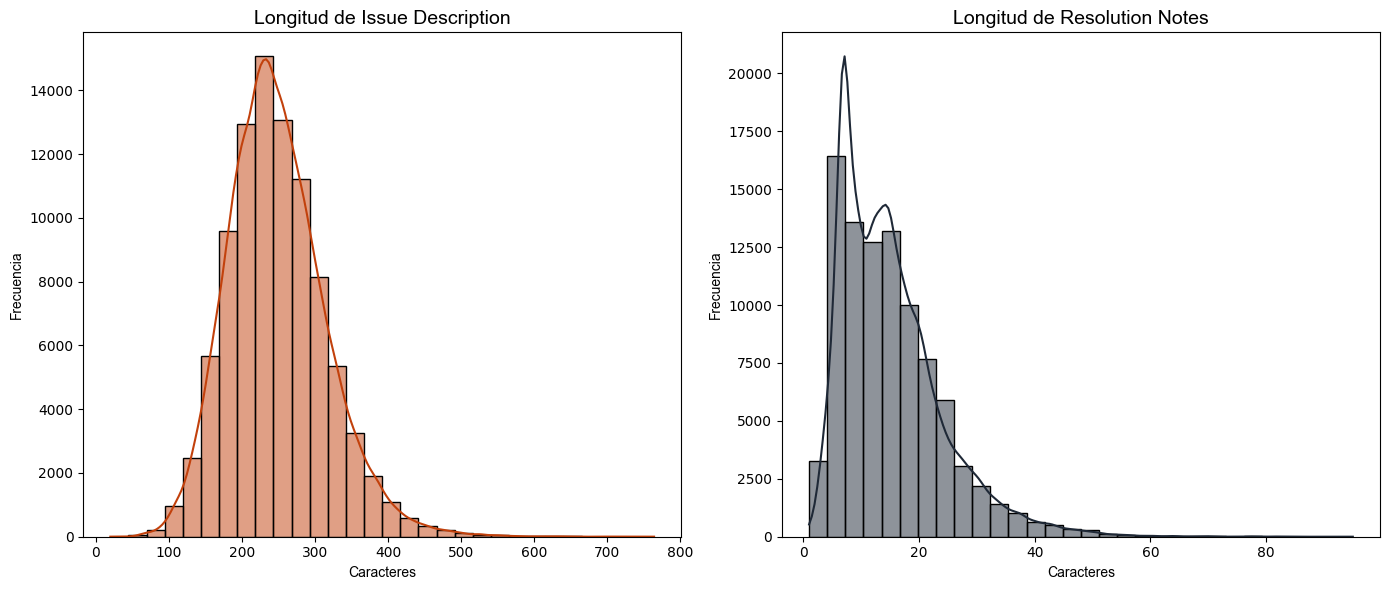

--- Estadísticas de Longitud (Caracteres) ---
       description_len  designation_len
count         92506.00         92506.00
mean            248.03            15.17
std              67.04             8.87
min              20.00             1.00
25%             202.00             8.00
50%             242.00            14.00
75%             288.00            20.00
max             764.00            95.00


In [ ]:
# Cálculo de longitudes (cantidad de caracteres)
df_nlp['description_len'] = df_nlp['description'].str.len()
df_nlp['designation_len'] = df_nlp['designation'].str.len()

# Configuración de la figura
plt.figure(figsize=(14, 6))

# Histograma para issue_description
plt.subplot(1, 2, 1)
sns.histplot(df_nlp['description_len'], bins=30, color='#C2410C', kde=True)
plt.title('Longitud de Issue Description', fontname='Arial', fontsize=14)
plt.xlabel('Caracteres', fontname='Arial')
plt.ylabel('Frecuencia', fontname='Arial')

# Histograma para resolution_notes
plt.subplot(1, 2, 2)
sns.histplot(df_nlp['designation_len'], bins=30, color='#1F2937', kde=True)
plt.title('Longitud de Resolution Notes', fontname='Arial', fontsize=14)
plt.xlabel('Caracteres', fontname='Arial')
plt.ylabel('Frecuencia', fontname='Arial')

plt.tight_layout()
plt.show()

# 3. Estadísticas descriptivas
print("--- Estadísticas de Longitud (Caracteres) ---")
print(df_nlp[['description_len', 'designation_len']].describe().round(2))